In [32]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('hotel_bookings.csv')
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

### Проверим на дубликаты

In [34]:
df.duplicated().sum()

np.int64(31994)

Нашлось 31994 дубликатов. Очистим датасет от них

In [ ]:
origin_shape0 = df.shape[0]
print(f'Количество строк до очистки от дубликатов: {origin_shape0}')
df = df.drop_duplicates()
print(f'Количество строк после удаления дубликатов: {df.shape[0]}. Дубликаты составляли {((origin_shape0 - df.shape[0]) / origin_shape0 * 100):.2f}% исходного датасета.')

Количество строк до очистки от дубликатов: 119390
Количество строк после удаления дубликатов: 87396. Дубликаты составляли 26.80% исходного датасета.


### Посмотрим каждый признак

#### Hotel

In [36]:
print(f'Пропусков у признака Hotel: {df['hotel'].isnull().sum()}')

Пропусков у признака Hotel: 0


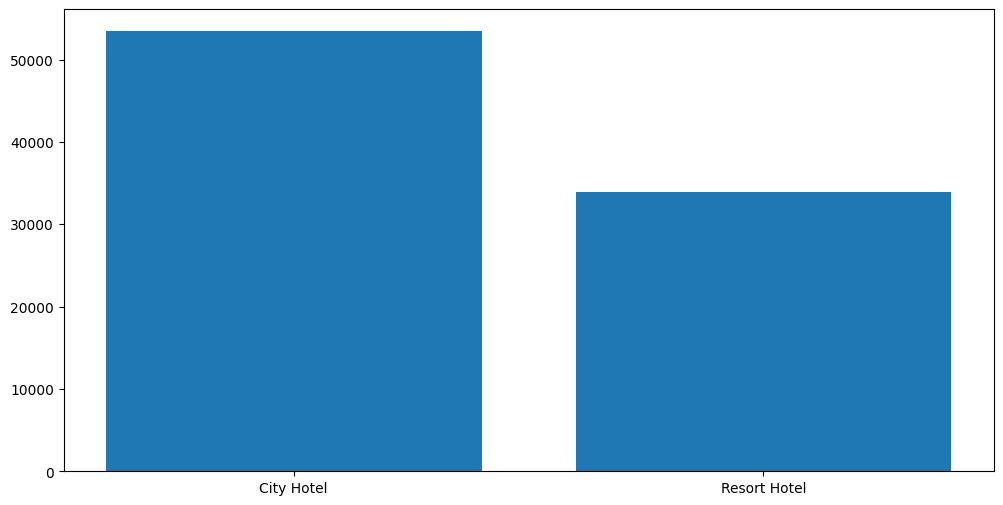

In [37]:

plt.figure(figsize=(12, 6))
plt.bar(df['hotel'].value_counts().index, df['hotel'].value_counts().values)
plt.show()

In [38]:
df['hotel'].value_counts() / df.shape[0] * 100

hotel
City Hotel      61.133233
Resort Hotel    38.866767
Name: count, dtype: float64

У нас всего два отеля: City Hotel - 61.13% и Resort Hotel - 38.87%. Пропусков нет. Можем предположить, что City Hotel более популярный в данном датасете - из-за меньшей привязки к сезонности, как, скорее всего, курортный отель - Resort Hotel. Но это будет рассмотрено уже в части анализа связи разных признаков.

#### is_canceled

In [39]:
print(f'Пропусков у признака is_canceled: {df['is_canceled'].isnull().sum()}')

Пропусков у признака is_canceled: 0


In [40]:
df['is_canceled'].value_counts() / df.shape[0] * 100

is_canceled
0    72.510184
1    27.489816
Name: count, dtype: float64

is_canceled - это основная целевая переменная - отменена ли бронь за отель. Мы видим дисбаланс классов, где не отменненых бронирований больше, но в реальности более высокое число успешных броней - нормально, почти 30% отмененных не так уж и мало.

#### lead_time

Это числовой признак, показывающий количество дней от даты внесения броня в базу, до дня прибытия 

In [41]:
print(f'Пропусков у признака lead_time: {df['lead_time'].isnull().sum()}')

Пропусков у признака lead_time: 0


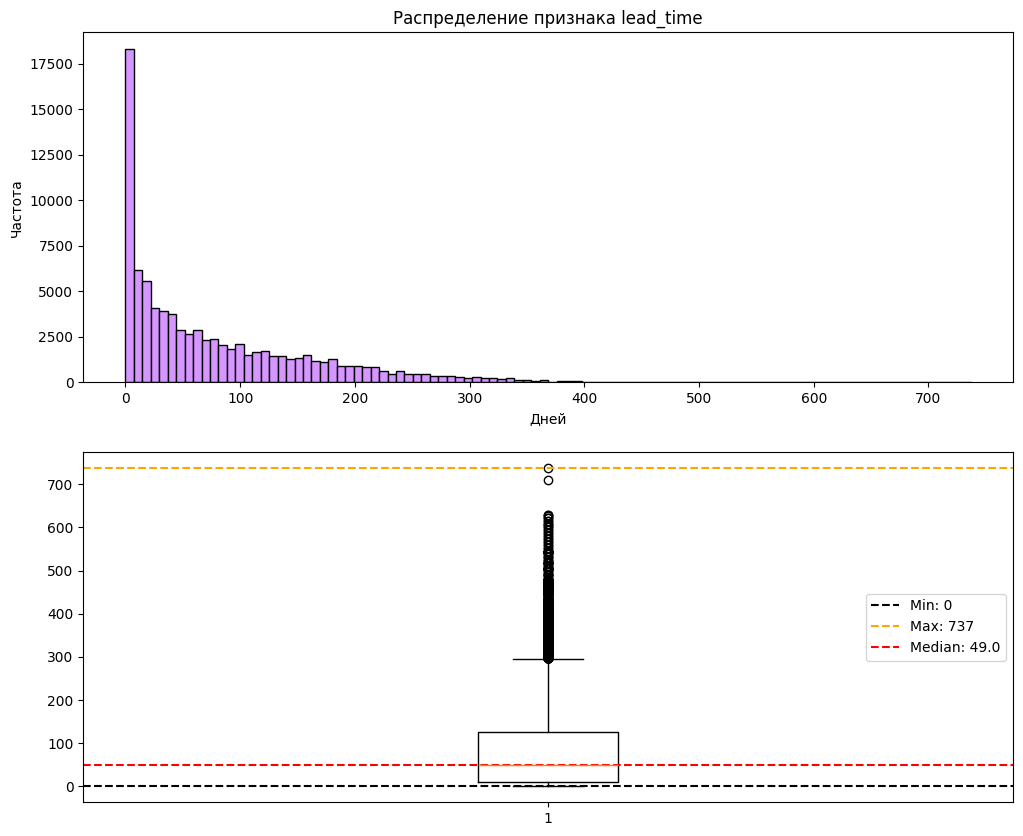

In [67]:
plt.figure(figsize=(12, 10))

plt.subplot(2,1,1)
plt.title('Распределение признака lead_time')
plt.hist(df['lead_time'], bins=100, edgecolor='black', color='#d596ff')
plt.xlabel('Дней')
plt.ylabel('Частота')

plt.subplot(2,1,2)
plt.boxplot(df['lead_time'])
plt.axhline(df['lead_time'].min(), color='black', linestyle='--', label=f'Min: {df['lead_time'].min()}')
plt.axhline(df['lead_time'].max(), color='orange', linestyle='--', label=f'Max: {df['lead_time'].max()}')
plt.axhline(df['lead_time'].median(), color='red', linestyle='--', label=f'Median: {df['lead_time'].median()}')
plt.legend()
plt.show()

#### arrival_date_year

In [24]:
print(f'Пропусков у признака arrival_date_year: {df['arrival_date_year'].isnull().sum()}')

Пропусков у признака arrival_date_year: 0


In [25]:
df['arrival_date_year'].value_counts() / df.shape[0] * 100

arrival_date_year
2016    47.497278
2017    34.079069
2015    18.423654
Name: count, dtype: float64

#### arrival_date_month

In [ ]:
print(f'Пропусков у признака arrival_date_month: {df['arrival_date_month'].isnull().sum()}')

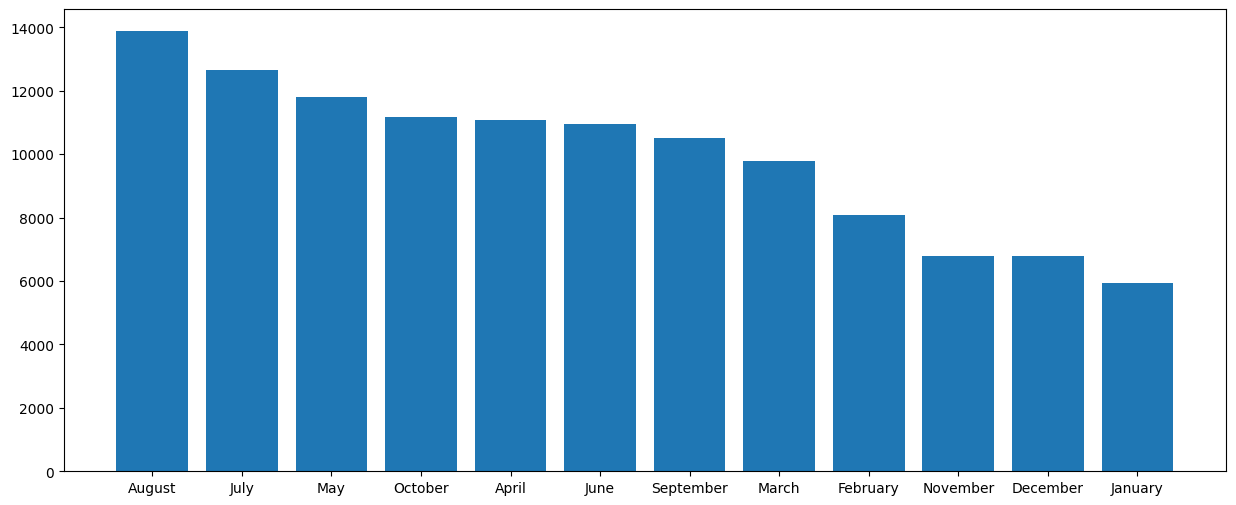

In [27]:
plt.figure(figsize=(15,6))
plt.bar(df['arrival_date_month'].value_counts().index, df['arrival_date_month'].value_counts().values)
plt.show()